 # 01 — Sampled Spectra: FPCA + Distance-Based Models



 This notebook evaluates distance-based classifiers on sampled calibrated spectra.



 Input:

 - `xp_sampled_spectra.csv`



 Main pipeline:

 1. load sampled spectra

 2. align labels

 3. apply row-wise L2 normalization

 4. perform FPCA using SVD

 5. classify FPCA scores with distance-based models



 Models:

 - Centroid

 - Medoid

 - kNN

 - Weighted kNN



 Distances:

 - Euclidean

 - Manhattan

 - Cosine

 - Correlation

 - Standardized Euclidean

 - Mahalanobis



 Evaluation:

 - Accuracy

 - Precision

 - Recall (Sensitivity)

 - Specificity

 - F1-score

Outputs:
- sampled_fpca_distance_models_results.csv
- sampled_fpca_distance_models_best_by_J.csv

In [1]:
from pathlib import Path

import os
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from sklearn.metrics import pairwise_distances



 ## 1. Configuration

In [ ]:
DATA_DIR = Path(".") / "og_data"
OUT_DIR = Path(".") / "results" / "final_functional"
os.makedirs(OUT_DIR, exist_ok=True)

SAMPLED_CANDIDATES = [
    DATA_DIR / "xp_sampled_spectra.csv",
]

RANDOM_STATE = 42
TEST_SIZE = 0.20
K_DEFAULT = 5

J_VALUES = [5, 10, 20, 30]

DISTANCES = [
    "euclidean",
    "manhattan",
    "cosine",
    "correlation",
    "seuclidean",
    "mahalanobis",
]



 ## 2. Helper functions

In [3]:
def find_first_existing(paths):
    """Return the first existing path from a list of candidate paths."""
    for path in paths:
        if path.exists():
            return path
    return None


def l2_normalize_rows(X, eps=1e-12):
    """Apply row-wise L2 normalization."""
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.maximum(norms, eps)
    return X / norms


def evaluate_binary(y_true, y_pred):
    """Compute standard binary classification metrics."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def fit_mahalanobis_matrix(X_tr, y_tr, eps=1e-4):
    """
    Estimate a pooled within-class covariance matrix and return its pseudo-inverse.
    """
    n_features = X_tr.shape[1]
    S = np.zeros((n_features, n_features))

    classes = np.unique(y_tr)
    for cls in classes:
        X_cls = X_tr[y_tr == cls]
        diff = X_cls - X_cls.mean(axis=0)
        S += diff.T @ diff

    denom = max(len(X_tr) - len(classes), 1)
    S /= denom
    S += eps * np.eye(n_features)

    return np.linalg.pinv(S)


def pairwise_distance_train_test(X_te, X_tr, metric_name, y_tr=None):
    """Compute distances between test and training objects."""
    if metric_name == "euclidean":
        return pairwise_distances(X_te, X_tr, metric="euclidean")

    if metric_name == "manhattan":
        return pairwise_distances(X_te, X_tr, metric="manhattan")

    if metric_name == "cosine":
        return pairwise_distances(X_te, X_tr, metric="cosine")

    if metric_name == "correlation":
        return pairwise_distances(X_te, X_tr, metric="correlation")

    if metric_name == "seuclidean":
        V = np.var(X_tr, axis=0, ddof=1)
        V = np.where(V <= 1e-12, 1e-12, V)
        return pairwise_distances(X_te, X_tr, metric="seuclidean", V=V)

    if metric_name == "mahalanobis":
        VI = fit_mahalanobis_matrix(X_tr, y_tr)
        return pairwise_distances(X_te, X_tr, metric="mahalanobis", VI=VI)

    raise ValueError(f"Unknown metric: {metric_name}")


def pairwise_distance_to_reference(X_te, X_ref, X_tr_ref, metric_name, y_tr=None):
    """
    Compute distances from test objects to reference points.
    For seuclidean and Mahalanobis, scaling is estimated from training data.
    """
    if metric_name == "euclidean":
        return pairwise_distances(X_te, X_ref, metric="euclidean")

    if metric_name == "manhattan":
        return pairwise_distances(X_te, X_ref, metric="manhattan")

    if metric_name == "cosine":
        return pairwise_distances(X_te, X_ref, metric="cosine")

    if metric_name == "correlation":
        return pairwise_distances(X_te, X_ref, metric="correlation")

    if metric_name == "seuclidean":
        V = np.var(X_tr_ref, axis=0, ddof=1)
        V = np.where(V <= 1e-12, 1e-12, V)
        return pairwise_distances(X_te, X_ref, metric="seuclidean", V=V)

    if metric_name == "mahalanobis":
        VI = fit_mahalanobis_matrix(X_tr_ref, y_tr)
        return pairwise_distances(X_te, X_ref, metric="mahalanobis", VI=VI)

    raise ValueError(f"Unknown metric: {metric_name}")


def centroid_predict(X_tr, y_tr, X_te, metric_name):
    """Predict using class centroids."""
    c0 = X_tr[y_tr == 0].mean(axis=0, keepdims=True)
    c1 = X_tr[y_tr == 1].mean(axis=0, keepdims=True)
    refs = np.vstack([c0, c1])

    D = pairwise_distance_to_reference(X_te, refs, X_tr, metric_name, y_tr)
    return np.argmin(D, axis=1)


def get_class_medoid(X_cls, X_tr_ref, y_tr, metric_name):
    """Return the class medoid under the selected metric."""
    if len(X_cls) == 1:
        return X_cls[0:1]

    D = pairwise_distance_to_reference(X_cls, X_cls, X_tr_ref, metric_name, y_tr)
    medoid_idx = np.argmin(D.sum(axis=1))
    return X_cls[medoid_idx:medoid_idx + 1]


def medoid_predict(X_tr, y_tr, X_te, metric_name):
    """Predict using class medoids."""
    m0 = get_class_medoid(X_tr[y_tr == 0], X_tr, y_tr, metric_name)
    m1 = get_class_medoid(X_tr[y_tr == 1], X_tr, y_tr, metric_name)
    refs = np.vstack([m0, m1])

    D = pairwise_distance_to_reference(X_te, refs, X_tr, metric_name, y_tr)
    return np.argmin(D, axis=1)


def knn_predict(X_tr, y_tr, X_te, metric_name, k):
    """Predict using standard k-nearest neighbors."""
    D = pairwise_distance_train_test(X_te, X_tr, metric_name, y_tr)
    idx = np.argsort(D, axis=1)[:, :k]
    return (y_tr[idx].mean(axis=1) > 0.5).astype(int)


def weighted_knn_predict(X_tr, y_tr, X_te, metric_name, k, eps=1e-8):
    """Predict using inverse-distance weighted k-nearest neighbors."""
    D = pairwise_distance_train_test(X_te, X_tr, metric_name, y_tr)
    idx = np.argsort(D, axis=1)[:, :k]

    d_k = np.take_along_axis(D, idx, axis=1)
    y_k = y_tr[idx]

    weights = 1.0 / (d_k + eps)
    weighted_prob = (weights * y_k).sum(axis=1) / weights.sum(axis=1)

    return (weighted_prob > 0.5).astype(int)


def fpca_fit_transform(X_tr, X_te, J):
    """
    Fit FPCA by SVD on training data and project both train and test data.

    Returns:
    - train scores
    - test scores
    - explained variance ratio
    - retained component variances
    - mean function
    - eigenfunctions
    """
    mu = X_tr.mean(axis=0)
    X_tr_c = X_tr - mu
    X_te_c = X_te - mu

    _, S, Vt = np.linalg.svd(X_tr_c, full_matrices=False)

    variances = (S ** 2) / max(len(X_tr) - 1, 1)
    explained_ratio = variances / variances.sum()

    J_eff = min(J, Vt.shape[0])
    Vj = Vt[:J_eff].T

    xi_tr = X_tr_c @ Vj
    xi_te = X_te_c @ Vj

    return xi_tr, xi_te, explained_ratio, variances[:J_eff], mu, Vt


def run_distance_models(X_tr, X_te, y_tr, y_te, feature_space, distances, k):
    """Run all distance-based models for one feature space."""
    rows = []

    for dist_name in distances:
        y_pred_cent = centroid_predict(X_tr, y_tr, X_te, dist_name)
        rows.append({
            "representation": "Sampled spectra",
            "feature_space": feature_space,
            "distance": dist_name,
            "model": "Centroid",
            **evaluate_binary(y_te, y_pred_cent),
        })

        y_pred_med = medoid_predict(X_tr, y_tr, X_te, dist_name)
        rows.append({
            "representation": "Sampled spectra",
            "feature_space": feature_space,
            "distance": dist_name,
            "model": "Medoid",
            **evaluate_binary(y_te, y_pred_med),
        })

        y_pred_knn = knn_predict(X_tr, y_tr, X_te, dist_name, k)
        rows.append({
            "representation": "Sampled spectra",
            "feature_space": feature_space,
            "distance": dist_name,
            "model": f"kNN (k={k})",
            **evaluate_binary(y_te, y_pred_knn),
        })

        y_pred_wknn = weighted_knn_predict(X_tr, y_tr, X_te, dist_name, k)
        rows.append({
            "representation": "Sampled spectra",
            "feature_space": feature_space,
            "distance": dist_name,
            "model": f"Weighted kNN (k={k})",
            **evaluate_binary(y_te, y_pred_wknn),
        })

    return rows



 ## 3. Load sampled spectra

In [4]:
sampled_path = find_first_existing(SAMPLED_CANDIDATES)

if sampled_path is None:
    raise FileNotFoundError(
        "No sampled spectra dataset found. Expected one of: "
        f"{[path.name for path in SAMPLED_CANDIDATES]}"
    )

df = pd.read_csv(sampled_path)
df["source_id"] = df["source_id"].astype(str)

wl_cols = sorted(
    [col for col in df.columns if col.startswith("wl_")],
    key=lambda col: int(col.split("_")[1]),
)

if not wl_cols:
    raise ValueError(
        "Sampled spectra file must contain wide wavelength columns "
        "(for example: wl_336, wl_338, ...)."
    )

if "y" not in df.columns:
    raise ValueError(
        "Sampled spectra file must contain a 'y' column. "
        "Use the aligned file from notebook 01 if needed."
    )

wavelengths = np.array([int(col.split("_")[1]) for col in wl_cols], dtype=float)

X_raw = df[wl_cols].to_numpy(dtype=float)
y = df["y"].to_numpy(dtype=int)

print("Using file:", sampled_path.name)
print("Dataset shape:", df.shape)
print("Sampled matrix shape:", X_raw.shape)
print("Wavelength range:", f"{wavelengths[0]:.0f} – {wavelengths[-1]:.0f} nm")
print("\nClass balance:")
print(pd.Series(y).value_counts().sort_index())



Using file: xp_sampled_spectra.csv
Dataset shape: (2815, 345)
Sampled matrix shape: (2815, 343)
Wavelength range: 336 – 1020 nm

Class balance:
0    2257
1     558
Name: count, dtype: int64


 ## 4. Normalize sampled spectra



 Unlike the coefficient representation, sampled spectra are normalized here

 to emphasize spectral shape rather than overall scale.

In [5]:
X = l2_normalize_rows(X_raw)

raw_norms = np.linalg.norm(X_raw, axis=1)
normed_norms = np.linalg.norm(X, axis=1)

print("Any missing values:", np.isnan(X).any())

print("\nRaw sampled row-norm summary:")
print(pd.Series(raw_norms).describe())

print("\nNormalized sampled row-norm summary:")
print(pd.Series(normed_norms).describe().round(6))



Any missing values:

 False

Raw sampled row-norm summary:
count    2.815000e+03
mean     2.475185e-15
std      1.351281e-14
min      6.110590e-17
25%      3.396496e-16
50%      7.016139e-16
75%      1.614415e-15
max      5.323431e-13
dtype: float64

Normalized sampled row-norm summary:
count    2815.000000
mean        0.002475
std         0.013513
min         0.000061
25%         0.000340
50%         0.000702
75%         0.001614
max         0.532343
dtype: float64


 ## 5. Train/test split

In [6]:
idx_all = np.arange(len(y))

idx_tr, idx_te, y_tr, y_te = train_test_split(
    idx_all,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_tr = X[idx_tr]
X_te = X[idx_te]

print("Train size:", len(idx_tr))
print("Test size:", len(idx_te))



Train size: 2252
Test size: 563


 ## 6. FPCA across several dimensions

In [7]:
results = []
fpca_info_rows = []

for J in J_VALUES:
    xi_tr, xi_te, explained_ratio, variances, mu_train, Vt = fpca_fit_transform(
        X_tr, X_te, J
    )

    fpca_info_rows.append({
        "J": len(variances),
        "cum_explained_variance": explained_ratio[:len(variances)].sum(),
    })

    results += run_distance_models(
        X_tr=xi_tr,
        X_te=xi_te,
        y_tr=y_tr,
        y_te=y_te,
        feature_space=f"FPCA (J={len(variances)})",
        distances=DISTANCES,
        k=K_DEFAULT,
    )

results_df = pd.DataFrame(results)

metric_cols = ["accuracy", "precision", "recall", "sensitivity", "specificity", "f1"]
results_df[metric_cols] = results_df[metric_cols].round(3)

print("\n=== RESULTS ===")
print(results_df.to_string(index=False))




=== RESULTS ===
 representation feature_space    distance              model  accuracy  precision  recall  sensitivity  specificity    f1
Sampled spectra    FPCA (J=5)   euclidean           Centroid     0.334      0.203   0.804        0.804        0.217 0.324
Sampled spectra    FPCA (J=5)   euclidean             Medoid     0.554      0.225   0.509        0.509        0.565 0.312
Sampled spectra    FPCA (J=5)   euclidean          kNN (k=5)     0.817      0.576   0.304        0.304        0.945 0.398
Sampled spectra    FPCA (J=5)   euclidean Weighted kNN (k=5)     0.813      0.554   0.321        0.321        0.936 0.407
Sampled spectra    FPCA (J=5)   manhattan           Centroid     0.336      0.204   0.804        0.804        0.220 0.325
Sampled spectra    FPCA (J=5)   manhattan             Medoid     0.565      0.233   0.518        0.518        0.576 0.321
Sampled spectra    FPCA (J=5)   manhattan          kNN (k=5)     0.812      0.545   0.321        0.321        0.933 0.404
Sampled

 ## 7. Best models by F1

In [8]:
best_df = results_df.sort_values("f1", ascending=False).reset_index(drop=True)

print("\n=== TOP MODELS BY F1 ===")
print(best_df.head(20).to_string(index=False))




=== TOP MODELS BY F1 ===
 representation feature_space    distance              model  accuracy  precision  recall  sensitivity  specificity    f1
Sampled spectra   FPCA (J=30)  seuclidean           Centroid     0.883      0.780   0.571        0.571        0.960 0.660
Sampled spectra   FPCA (J=20)  seuclidean           Centroid     0.870      0.735   0.545        0.545        0.951 0.626
Sampled spectra   FPCA (J=20)  seuclidean Weighted kNN (k=5)     0.877      0.803   0.509        0.509        0.969 0.623
Sampled spectra   FPCA (J=20)  seuclidean          kNN (k=5)     0.877      0.803   0.509        0.509        0.969 0.623
Sampled spectra   FPCA (J=20) correlation Weighted kNN (k=5)     0.858      0.678   0.545        0.545        0.936 0.604
Sampled spectra   FPCA (J=20) correlation          kNN (k=5)     0.856      0.674   0.536        0.536        0.936 0.597
Sampled spectra   FPCA (J=10)  seuclidean          kNN (k=5)     0.851      0.646   0.554        0.554        0.925 0.59

 ## 8. Best model within each FPCA dimension

In [9]:
summary_df = (
    results_df
    .sort_values(["feature_space", "f1"], ascending=[True, False])
    .groupby("feature_space", as_index=False)
    .first()
)

print("\n=== BEST MODEL WITHIN EACH FPCA SETTING ===")
print(summary_df.to_string(index=False))




=== BEST MODEL WITHIN EACH FPCA SETTING ===
feature_space  representation   distance              model  accuracy  precision  recall  sensitivity  specificity    f1
  FPCA (J=10) Sampled spectra seuclidean          kNN (k=5)     0.851      0.646   0.554        0.554        0.925 0.596
  FPCA (J=20) Sampled spectra seuclidean           Centroid     0.870      0.735   0.545        0.545        0.951 0.626
  FPCA (J=30) Sampled spectra seuclidean           Centroid     0.883      0.780   0.571        0.571        0.960 0.660
   FPCA (J=5) Sampled spectra seuclidean Weighted kNN (k=5)     0.838      0.606   0.536        0.536        0.914 0.569


 ## 9. FPCA explained variance

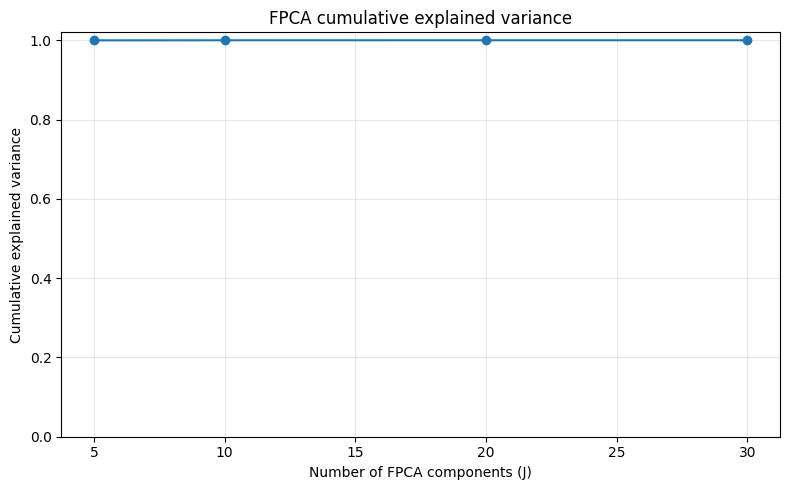

In [10]:
fpca_info_df = pd.DataFrame(fpca_info_rows)

plt.figure(figsize=(8, 5))
plt.plot(
    fpca_info_df["J"],
    fpca_info_df["cum_explained_variance"],
    marker="o",
)
plt.xlabel("Number of FPCA components (J)")
plt.ylabel("Cumulative explained variance")
plt.title("FPCA cumulative explained variance")
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



 ## 10. Top-model comparison plot

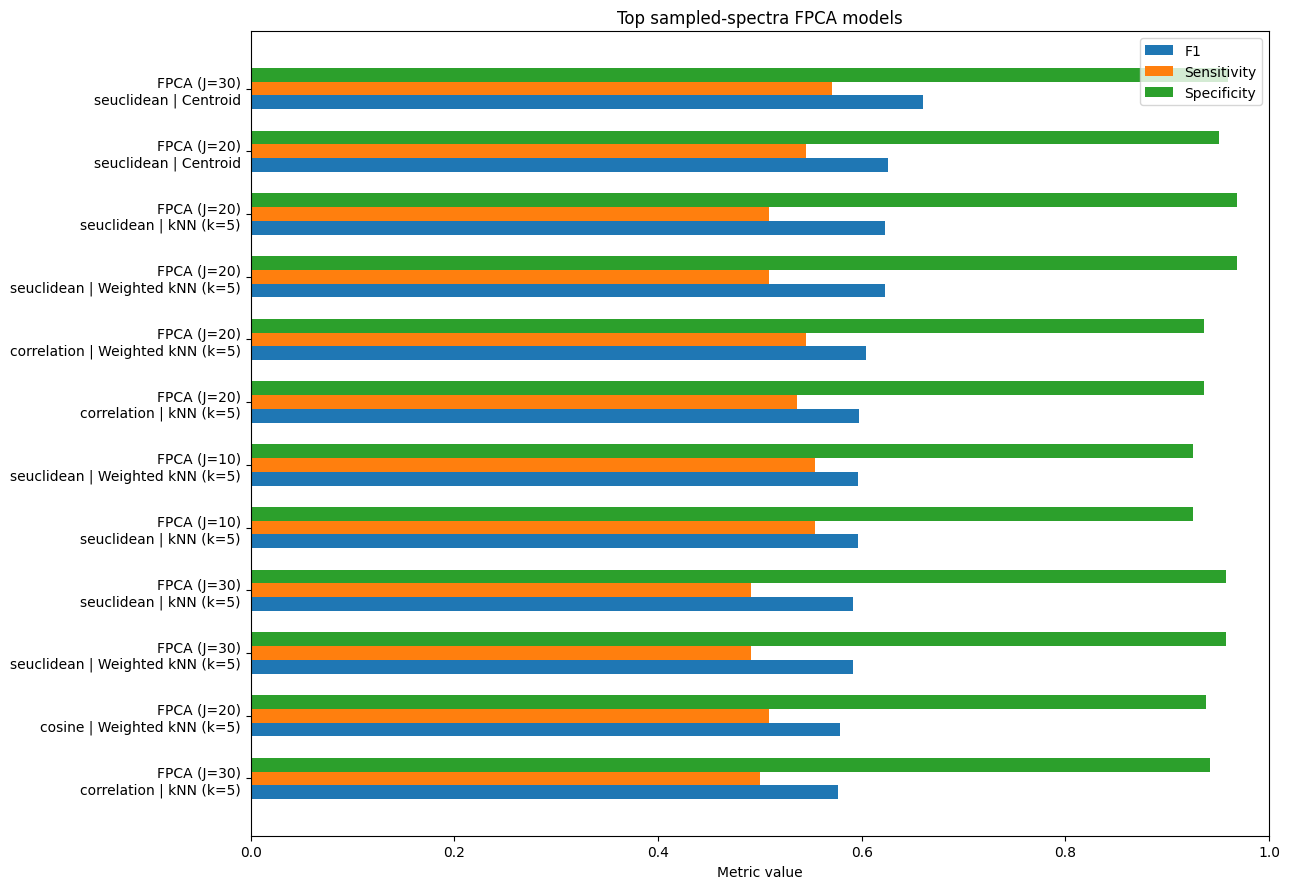

In [11]:
top_n = 12

plot_df = results_df.copy()
plot_df["label"] = (
    plot_df["feature_space"]
    + "\n"
    + plot_df["distance"]
    + " | "
    + plot_df["model"]
)

plot_df = plot_df.sort_values("f1", ascending=False).head(top_n).copy()
plot_df = plot_df.sort_values("f1", ascending=True)

y_pos = np.arange(len(plot_df))
bar_height = 0.22

plt.figure(figsize=(13, 9))
plt.barh(y_pos - bar_height, plot_df["f1"], height=bar_height, label="F1")
plt.barh(y_pos, plot_df["sensitivity"], height=bar_height, label="Sensitivity")
plt.barh(
    y_pos + bar_height,
    plot_df["specificity"],
    height=bar_height,
    label="Specificity",
)

plt.yticks(y_pos, plot_df["label"])
plt.xlabel("Metric value")
plt.title("Top sampled-spectra FPCA models")
plt.xlim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()



 ## 11. Distance comparison within FPCA space

In [12]:
pivot_df = results_df.pivot_table(
    index=["feature_space", "distance"],
    columns="model",
    values="f1",
)

print("\n=== F1 BY FPCA SETTING AND DISTANCE ===")
print(pivot_df.round(3))




=== F1 BY FPCA SETTING AND DISTANCE ===
model                      Centroid  Medoid  Weighted kNN (k=5)  kNN (k=5)
feature_space distance                                                    
FPCA (J=10)   correlation     0.321   0.378               0.559      0.560
              cosine          0.321   0.395               0.544      0.562
              euclidean       0.324   0.312               0.452      0.443
              mahalanobis     0.324   0.312               0.486      0.469
              manhattan       0.325   0.319               0.451      0.451
              seuclidean      0.500   0.541               0.596      0.596
FPCA (J=20)   correlation     0.321   0.383               0.604      0.597
              cosine          0.321   0.385               0.579      0.574
              euclidean       0.324   0.312               0.411      0.405
              mahalanobis     0.324   0.316               0.446      0.437
              manhattan       0.325   0.318               0

 ## 12. Eigenspectra from the largest FPCA model

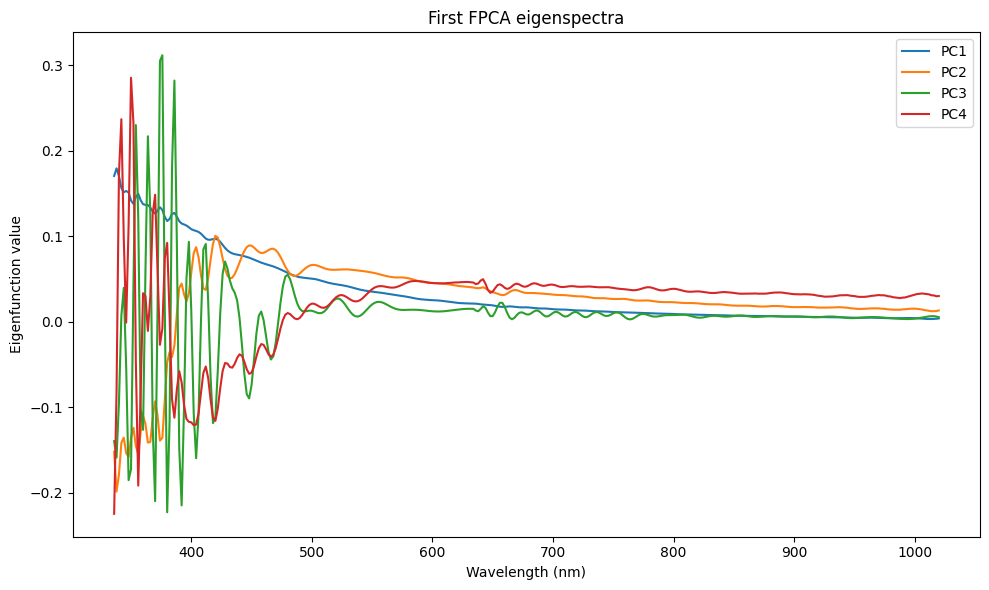

In [13]:
J_plot = max(J_VALUES)
_, _, explained_ratio_plot, variances_plot, mu_plot, Vt_plot = fpca_fit_transform(
    X_tr, X_te, J_plot
)

n_plot = min(4, Vt_plot.shape[0])

plt.figure(figsize=(10, 6))
for i in range(n_plot):
    plt.plot(wavelengths, Vt_plot[i], label=f"PC{i + 1}")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Eigenfunction value")
plt.title("First FPCA eigenspectra")
plt.legend()
plt.tight_layout()
plt.show()



 ## 13. Mean normalized spectra by class

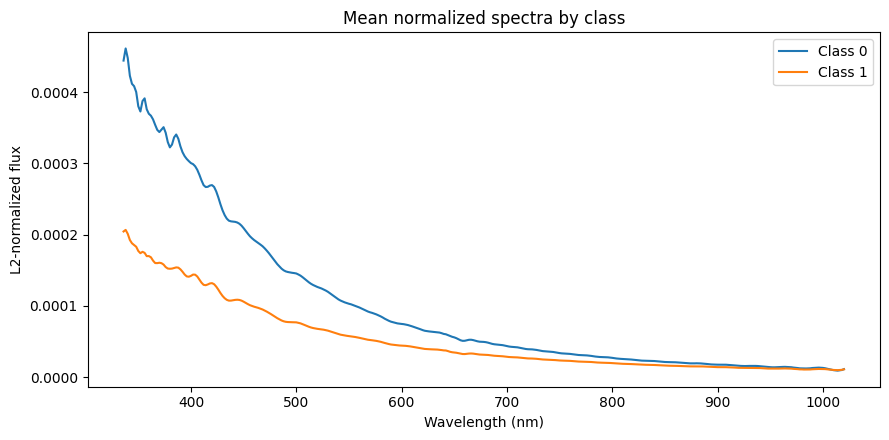

In [14]:
mu_0 = X[y == 0].mean(axis=0)
mu_1 = X[y == 1].mean(axis=0)

plt.figure(figsize=(9, 4.5))
plt.plot(wavelengths, mu_0, label="Class 0")
plt.plot(wavelengths, mu_1, label="Class 1")
plt.xlabel("Wavelength (nm)")
plt.ylabel("L2-normalized flux")
plt.title("Mean normalized spectra by class")
plt.legend()
plt.tight_layout()
plt.show()



 ## 14. Separation strength across wavelength

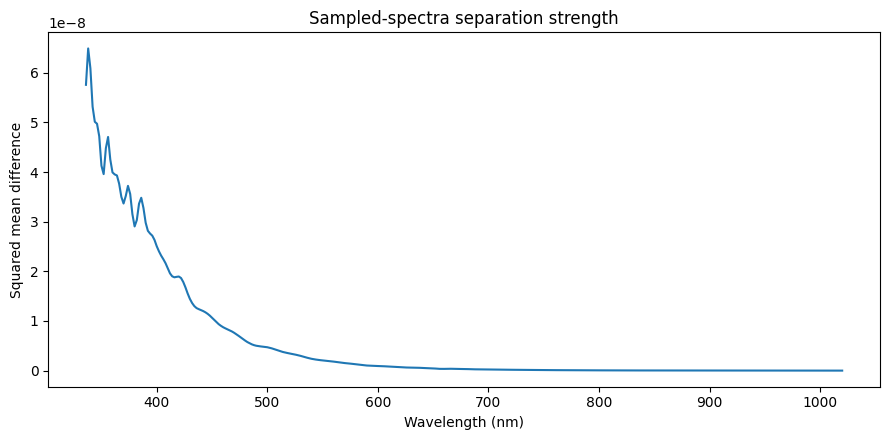

In [15]:
plt.figure(figsize=(9, 4.5))
plt.plot(wavelengths, (mu_1 - mu_0) ** 2)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Squared mean difference")
plt.title("Sampled-spectra separation strength")
plt.tight_layout()
plt.show()

## 15. Export

In [16]:
notebook_name = "01_sampled_fpca_distance_models"
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

results_df.to_csv(f"{OUT_DIR}/{notebook_name}_results_{timestamp}.csv", index=False)
summary_df.to_csv(f"{OUT_DIR}/{notebook_name}_best_by_J_{timestamp}.csv", index=False)

print("Saved:")
print("- " + f"{notebook_name}_results_{timestamp}.csv")
print("- " + f"{notebook_name}_best_by_J_{timestamp}.csv")

Saved:
- 01_sampled_fpca_distance_models_results_20260409_2003.csv
- 01_sampled_fpca_distance_models_best_by_J_20260409_2003.csv
